# CATS AND DOGS

In the proccess of this project we will discuss the quality of various Neural Network models to analyse and Classify a Dataset of 37 types of cat and dog races. This short study will be done using a Dataset provided by Oxford University called : Oxford-IIIT Pet Dataset. 

The project is divided in 5 different steps :

- Exploration of the Dataset
- Binary Classification between cats and dogs
- Classification between 37 cat and dog races
- Animal Segmentation
- Comparative Analyses

In [1]:
%load_ext autoreload
%autoreload 2

import random

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


100%|██████████| 792M/792M [00:16<00:00, 46.8MB/s] 
100%|██████████| 19.2M/19.2M [00:00<00:00, 22.0MB/s]


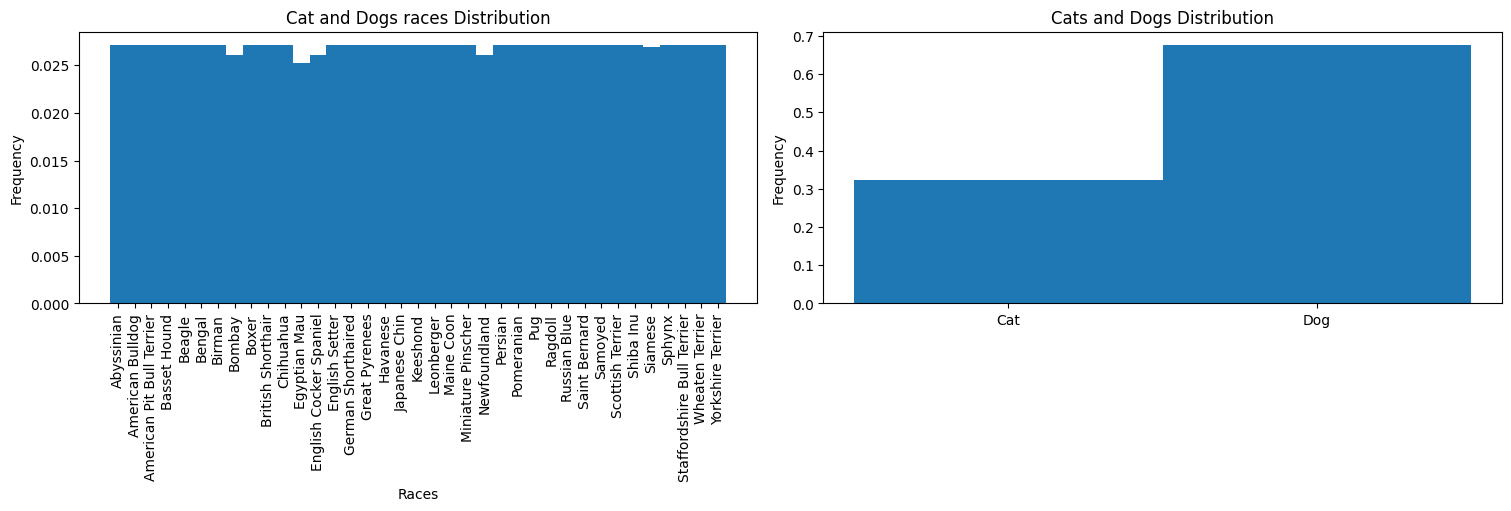

In [2]:
datapath = '../data/data_cats_and_dogs'
transform = torchvision.transforms.ToTensor()
dataset = torchvision.datasets.OxfordIIITPet(root=datapath, target_types="binary-category", download=True, transform=transform)

def get_data_statistics(dataset):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")

    axes[0].hist(dataset._labels, bins=np.arange(38)-0.5, density=True)
    axes[0].set_title('Cat and Dogs races Distribution')
    axes[0].set_xlabel('Races')
    axes[0].set_xticks(np.arange(37))
    axes[0].set_xticklabels(list(dataset.classes))
    axes[0].set_ylabel('Frequency')
    axes[0].tick_params(axis='x', rotation=90)
    
    axes[1].hist(dataset._bin_labels, bins=np.arange(3)-0.5, density=True)
    axes[1].set_title('Cats and Dogs Distribution')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(list(dataset.bin_classes))
    axes[1].set_ylabel('Frequency')
    plt.show()

get_data_statistics(dataset)

Il y a nettement plus d'images de chiens que de chats</p>
Les 37 races sont globalement équilibrées

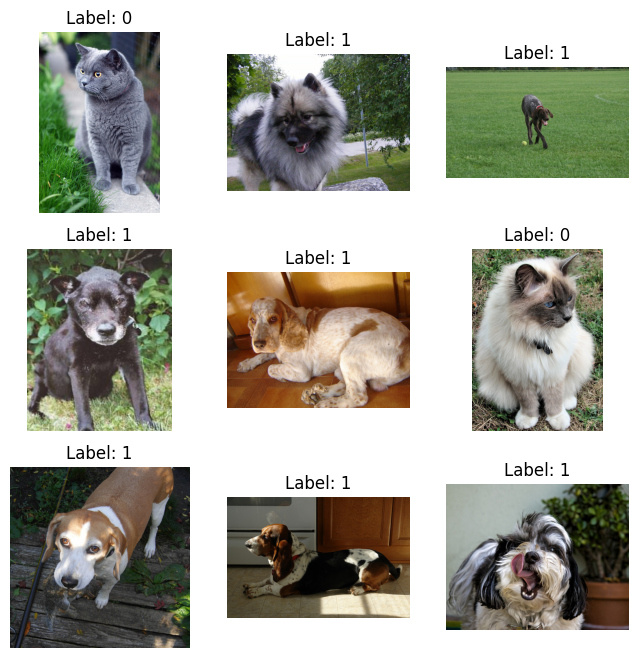

In [4]:
# fonction à insérer dans utils
# Plot 9 random images from the MNIST train dataset
def plot_images(img_dataset, RGB='True'):
    """Plots 9 random images from the given dataset

    Args:
        img_dataset (torch.utils.data.Dataset): The dataset to plot images from
    """
    # Set up a 3x3 grid for plotting 9 random images
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3, 3
    
    # Plot 9 random images from the img_dataset
    for i in range(1, cols * rows + 1):
        random_idx = torch.randint(len(img_dataset), size=(1,)).item()  # Pick a random index
        img, label = img_dataset[random_idx]  # Get the image and its label
        figure.add_subplot(rows, cols, i)  # Add subplot
        plt.title(f'Label: {label}')  # Set title to show the label
        plt.axis("off")  # Turn off axis
        if RGB == 'True':
            plt.imshow(torch.permute(img.squeeze(),(1,2,0)))  # Plot image
        else:
            plt.imshow(img.squeeze())  # Plot image
    
    plt.show()  # Display the figure

plot_images(dataset)

Biais visuels possibles :</p>
Animaux parfois entiers, parfois coupés, luminosité parfois mauvaise, la résolution est bonne mais nous devrons probablement la dégrader pour pouvoir entrainer un CNN. La taille des images devra être modifiée pour qu'elles aient toutes les mêmes dimensions

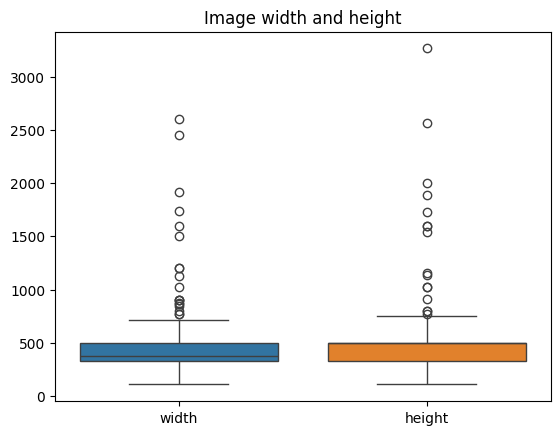

In [5]:
# Boxplots shapes of the images:

img_sizes = []
for i in range(3680):
    img, _ = dataset[i]
    img_sizes.append([np.shape(img)[1], np.shape(img)[2]])

import seaborn as sns
plt.figure()
ax = sns.boxplot(np.array(img_sizes))
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(['width', 'height'])
plt.title("Image width and height")
plt.show()

In [6]:
print(f'mean width: {int(np.mean(img_sizes))}, mean height: {int(np.mean(img_sizes))}')

mean width: 407, mean height: 407


#### Reshapping images to the mean shape

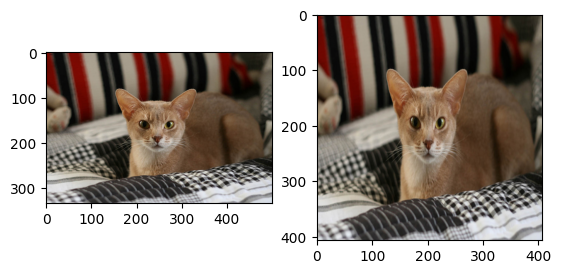

In [8]:
# test sur une image

from torchvision.transforms import Resize, ToTensor, InterpolationMode
import torch.nn.functional as F

resizing = Resize((407, 407))
img, _ = dataset[25]
img_new = resizing(img)
fig, axs = plt.subplots(1,2)
axs[0].imshow(torch.permute(img.squeeze(),(1,2,0)))
axs[1].imshow(torch.permute(img_new.squeeze(),(1,2,0)))

The mean value may be to high to train the model efficiently, it will probably be choosen lowaer than 407 at the end to train the model

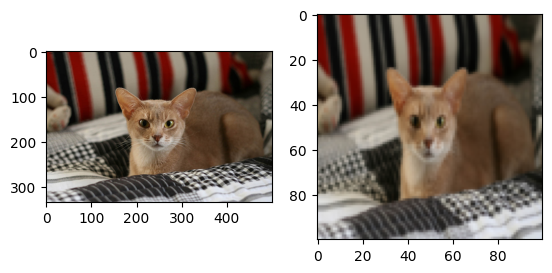

In [9]:
resizing = Resize((100, 100))
img, _ = dataset[25]
img_new = resizing(img)
fig, axs = plt.subplots(1,2)
axs[0].imshow(torch.permute(img.squeeze(),(1,2,0)))
axs[1].imshow(torch.permute(img_new.squeeze(),(1,2,0)))

In [10]:
## FONCTION IMPORTATION DES DONNEES choix de la taille des images, de la taille du batch et de la catégorie (espèce, race ou segmentation)

def get_datasets_loaders(batch_size, target_types:str="binary-category", resize=False, size=None):
    """_gets datasets and dataloaders for the OxfordIIIPet dataset depending on the targeted labels or segmentation_

    Args:
        batch_size (int): batch size
        target_types (str): _
            "binary-category" : cats / dogs, 
            "category" : cats and dogs races, 
            "segmentation" : PIL image segmentation trimap of the images
        resize (bool): resize the images
        size (tuple): resize the images with this size_.
    """
    transform = transforms.Compose([transforms.ToTensor()])
    if resize == True:
        transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size),torchvision.transforms.ToTensor()])
    
    train_dataset = datasets.OxfordIIITPet(root=datapath, split="trainval", target_types=target_types, transform=transform, download=True) #transform=transform,
    test_dataset = datasets.OxfordIIITPet(root=datapath, split="test", target_types=target_types, transform=transform, download=True) #transform=transform

    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    return train_dataset, test_dataset, train_loader, test_loader

<p>IMPORTANT NOTE : the transform argument enables to influence the entry (the image to recognize), it transforms it into a tensor, when the resize argument is True, before converting the image into a tensor, the torchvision function Resize() is applied to the image, so this function is composed with the torchvision function <b>ToTensor()</b>. Removing the composition and keeping only the <b>Resize()</b> function will return a dataset with PIL.Images as entries. The choice of the "target_types" enables to choose between a binary category classification (cats and dogs), a race classification or a segmentation. However using keys such as 'classes' or 'bin_classes' unables to access the different classifications even if one was choosen as a target_types.</p>

In [11]:
batch_size = 20 

img_width, img_height = 407, 407 # may be choosen smaller for training efficiency
size = (img_width, img_height)

In [12]:
train_dataset, test_dataset, train_loader, test_loader = get_datasets_loaders(batch_size, target_types="binary-category", resize=True, size=size)

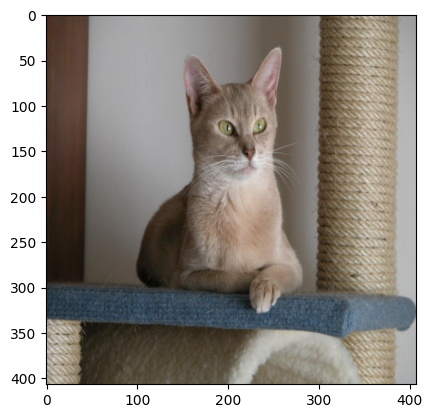

In [13]:
img, label = train_dataset[40]
np.shape(img)
plt.imshow(torch.permute(img.squeeze(),(1,2,0)))

test branche test